# Práctica: Estadística Descriptiva

En este notebook aplicamos los conceptos teóricos de `teoria.qmd` sobre un dataset simulado de **salarios de empleados por departamento**. Compararemos:

1. Cálculo manual con NumPy
2. Funciones nativas de `pandas`
3. Nuestro propio módulo `stats_toolkit.descriptive`

> Requisitos: `numpy`, `pandas`, `matplotlib`, `seaborn`, `scipy`

In [1]:
import sys
sys.path.append("../../src")  # permite importar stats_toolkit desde notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from stats_toolkit import descriptive as desc

sns.set_theme(style="whitegrid")
np.random.seed(42)

## 1. Generación del dataset simulado

Simulamos 300 empleados distribuidos en 4 departamentos. Los salarios siguen una distribución log-normal (común en datos salariales reales: asimétrica hacia la derecha, con pocos sueldos muy altos).

In [2]:
departamentos = ["Ventas", "IT", "RRHH", "Direccion"]
n_por_depto = 75

data = []
medias_log = {"Ventas": 7.2, "IT": 7.5, "RRHH": 7.1, "Direccion": 8.0}

for depto in departamentos:
    salarios = np.random.lognormal(mean=medias_log[depto], sigma=0.3, size=n_por_depto)
    for s in salarios:
        data.append({"departamento": depto, "salario": round(s, 2)})

df = pd.DataFrame(data)
df.head()

,departamento,salario
0,Ventas,1554.66
1,Ventas,1285.01
2,Ventas,1626.70
3,Ventas,2115.21
4,Ventas,1248.57


## 2. Exploración inicial

Antes de calcular cualquier estadístico, revisamos la estructura general del dataset.

In [3]:
print(df.shape)
df.info()

(300, 2)
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   departamento  300 non-null    str    
 1   salario       300 non-null    float64
dtypes: float64(1), str(1)
memory usage: 4.8 KB


In [4]:
df.groupby("departamento")["salario"].describe()

,count,mean,std,min,25%,50%,75%,max
departamento,,,,,,,,
Direccion,75.0,3110.420800,964.050824,1127.34,2432.820,3021.99,3645.550,5671.35
IT,75.0,1852.882533,546.253702,995.98,1495.110,1810.82,2062.555,3785.65
RRHH,75.0,1333.960533,476.020440,692.16,983.245,1306.55,1482.425,3849.97
Ventas,75.0,1347.061733,384.226824,610.38,1098.500,1285.01,1565.425,2334.80


## 3. Medidas de tendencia central: manual vs. `pandas` vs. `stats_toolkit`

Calculamos media, mediana y moda del salario global de tres formas distintas para verificar consistencia.

In [5]:
salarios = df["salario"].values

# 1) Manual con NumPy
media_manual = np.sum(salarios) / len(salarios)
mediana_manual = np.median(salarios)

# 2) Con pandas
media_pandas = df["salario"].mean()
mediana_pandas = df["salario"].median()

# 3) Con nuestro módulo
resultado_desc = desc.central_tendency(salarios)

print(f"Media    -> manual: {media_manual:.2f} | pandas: {media_pandas:.2f} | stats_toolkit: {resultado_desc['mean']:.2f}")
print(f"Mediana  -> manual: {mediana_manual:.2f} | pandas: {mediana_pandas:.2f} | stats_toolkit: {resultado_desc['median']:.2f}")
print(f"Moda (stats_toolkit): {resultado_desc['mode']:.2f}")

Media    -> manual: 1911.08 | pandas: 1911.08 | stats_toolkit: 1911.08
Mediana  -> manual: 1620.90 | pandas: 1620.90 | stats_toolkit: 1620.90
Moda (stats_toolkit): 610.38


**Observación:** los tres métodos coinciden, como es de esperar. La ventaja de `stats_toolkit` es que centraliza la lógica y evita repetir código en cada notebook del curso.

## 4. Medidas de dispersión

Comparamos la dispersión salarial entre departamentos usando el coeficiente de variación, que nos permite comparar variabilidad relativa aunque los promedios sean distintos.

In [6]:
for depto in departamentos:
    salarios_depto = df.loc[df["departamento"] == depto, "salario"].values
    disp = desc.dispersion(salarios_depto)
    print(f"{depto:12s} | media: {salarios_depto.mean():8.2f} | std: {disp['std']:7.2f} | CV: {disp['cv_pct']:5.2f}%")

Ventas       | media:  1347.06 | std:  384.23 | CV: 28.52%
IT           | media:  1852.88 | std:  546.25 | CV: 29.48%
RRHH         | media:  1333.96 | std:  476.02 | CV: 35.68%
Direccion    | media:  3110.42 | std:  964.05 | CV: 30.99%


## 5. Visualización de la distribución

Un histograma y un boxplot revelan lo que los números por sí solos no siempre muestran: la forma de la distribución y la presencia de outliers.

/tmp/ipykernel_140/495683293.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="departamento", y="salario", ax=axes[1], palette="Set2")


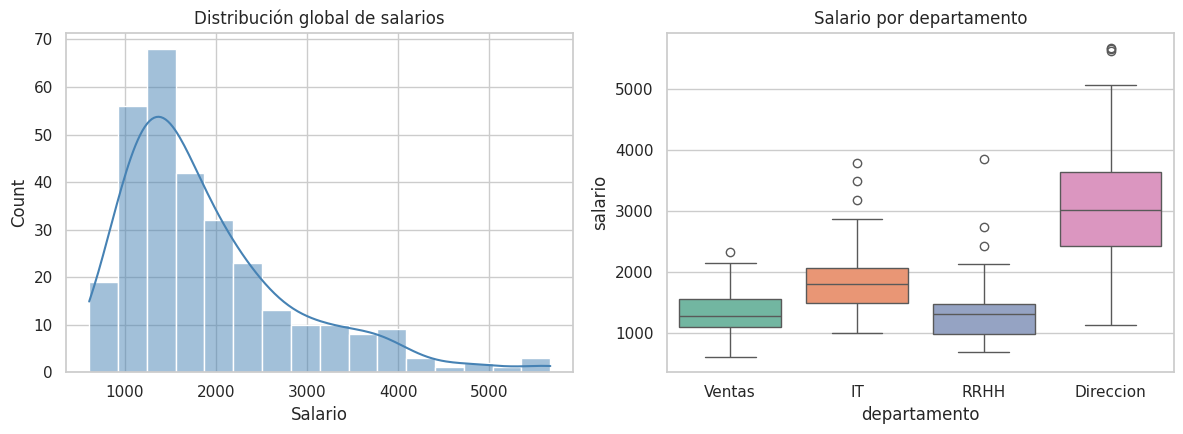

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df["salario"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución global de salarios")
axes[0].set_xlabel("Salario")

sns.boxplot(data=df, x="departamento", y="salario", ax=axes[1], palette="Set2")
axes[1].set_title("Salario por departamento")

plt.tight_layout()
plt.show()

## 6. Asimetría, curtosis y detección de outliers

In [8]:
forma = desc.shape(salarios)
print(f"Asimetría (skewness): {forma['skewness']:.3f}")
print(f"Curtosis de exceso:   {forma['kurtosis_excess']:.3f}")

outliers = desc.detect_outliers(salarios)
print(f"\nNúmero de outliers detectados (regla 1.5*IQR): {len(outliers)}")
print(f"Valores: {np.round(outliers, 2)}")

Asimetría (skewness): 1.442
Curtosis de exceso:   2.105

Número de outliers detectados (regla 1.5*IQR): 11
Valores: [4132.7  5671.35 5062.6  5634.41 4063.25 4359.33 4864.52 4593.43 4225.74
 4797.28 5652.82]


**Interpretación esperada:** al provenir de una distribución log-normal, la asimetría debería ser positiva (cola derecha), consistente con lo discutido en la teoría sobre distribuciones salariales.

## 7. Resumen completo con `stats_toolkit.summary_statistics`

En lugar de llamar función por función, `summary_statistics` devuelve todo en un solo diccionario — útil para generar reportes automáticos.

In [9]:
resumen_completo = desc.summary_statistics(salarios)
resumen_completo

{'n': 300,
 'central_tendency': {'mean': 1911.0813999999998,
  'median': 1620.9,
  'mode': 610.38},
 'dispersion': {'range': 5060.97,
  'variance': 921481.9622160936,
  'std': 959.9385200189091,
  'cv_pct': 50.230122066956916},
 'shape': {'skewness': 1.4421799362239542,
  'kurtosis_excess': 2.1050969630474077},
 'five_number_summary': {'min': 610.38,
  'q1': 1246.165,
  'median': 1620.9,
  'q3': 2318.915,
  'max': 5671.35,
  'iqr': 1072.75}}

## 8. Ejercicio propuesto

> **Tu turno:** usando `stats_toolkit.descriptive`, calcula el resumen estadístico completo **solo para el departamento de Dirección** y compáralo con el de Ventas. ¿Qué diferencias observas en el coeficiente de variación y en la asimetría? ¿Tiene sentido de negocio ese resultado?

```python
# Escribe tu solución aquí
salarios_direccion = df.loc[df["departamento"] == "Direccion", "salario"].values
salarios_ventas = df.loc[df["departamento"] == "Ventas", "salario"].values

# desc.summary_statistics(...)
```